# load filtered narrative-dataset

In [1]:
# load the filtered data
# import all semscho papers before any filtering
import pandas as pd
import glob
import json

# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

#files = glob.glob("../../data/processed/search_results_batch_*.jsonl")
files = glob.glob("../../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

oa_df = pd.DataFrame(records)

print(oa_df.shape)
print(oa_df.columns)

Found 4 files
(311686, 33)
Index(['paperId', 'title', 'venue', 'year', 'citationCount', 'fieldsOfStudy',
       'publicationTypes', 'authors', 'abstract', 'doi', 'pdf_url', 'oa_id',
       'oa_title', 'oa_publication_year', 'oa_language', 'oa_type',
       'oa_is_retracted', 'oa_cited_by_count',
       'oa_citation_normalized_percentile', 'oa_authors',
       'oa_source_display_name', 'oa_source_issn', 'oa_source_issn_l',
       'oa_source_type', 'oa_source_host_organization_name', 'oa_pdf_url',
       'oa_topics', 'oa_keywords', 'oa_concepts', 'oa_has_pdf',
       'oa_has_grobid_xml', 'oa_content_urls', 'abstract_source'],
      dtype='str')


In [2]:
import pandas as pd

OA_fields = [
    'Agricultural and Biological Sciences',
    'Arts and Humanities',
    'Biochemistry, Genetics and Molecular Biology',
    'Business, Management and Accounting',
    'Chemical Engineering',
    'Chemistry',
    'Computer Science',
    'Decision Sciences',
    'Dentistry',
    'Earth and Planetary Sciences',
    'Economics, Econometrics and Finance',
    'Energy',
    'Engineering',
    'Environmental Science',
    'Health Professions',
    'Immunology and Microbiology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Neuroscience',
    'Nursing',
    'Pharmacology, Toxicology and Pharmaceutics',
    'Physics and Astronomy',
    'Psychology',
    'Social Sciences',
    'Veterinary',
    'Social Sciences',
    'Social Sciences',
    'Social Sciences',
    'Arts and Humanities',
    'Arts and Humanities',
    'Missing_OA',
    ]


SemScho_fos = [
    'Biology',
    'Art',
    'Biology',
    'Business',
    'Engineering',
    'Chemistry',
    'Computer Science',
    'Psychology', # decision science
    'Medicine',
    'Geology',
    'Economics',
    'Engineering', #Energy
    'Engineering',
    'Environmental Science',
    'Medicine',
    'Biology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Biology',
    'Medicine',
    'Biology',
    'Physics',
    'Psychology',
    'Social Sciences',
    'Medicine',
    'Sociology',
    'Political Science',
    'Geography',
    'History',
    'Philosophy',
    #'Education', #
    #'Agricultural and Food Sciences',#
    #'Law',#
    #'Linguistics'#
    'Missing_SemScho'
    ]

new_cat = [
    'Biology',
    'Arts and Humanities',
    'Biology',
    'Business, Management and Accounting',
    'Engineering',
    'Chemistry',
    'Computer Science',
    'Psychology', # decision science
    'Medicine',
    'Earth and Planetary Sciences',
    'Economics, Econometrics and Finance',
    'Engineering', #Energy
    'Engineering',
    'Environmental Science',
    'Medicine',
    'Biology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Biology',
    'Medicine',
    'Biology',
    'Physics and Astronomy',
    'Psychology',
    'Social Sciences',
    'Medicine',
    'Social Sciences',
    'Social Sciences',
    'Social Sciences',
    'Arts and Humanities',
    'Arts and Humanities',
    'Missing'
    ]

print(len(set(OA_fields)))
print(len(set(SemScho_fos)))
print(len(set(new_cat)))

match_df = pd.DataFrame({'OA_fields': OA_fields, 'SemScho_fos': SemScho_fos, 'combined': new_cat}).sort_values(by=["combined"])
match_df

27
21
16


,OA_fields,SemScho_fos,combined
1,Arts and Humanities,Art,Arts and Humanities
29,Arts and Humanities,History,Arts and Humanities
30,Arts and Humanities,Philosophy,Arts and Humanities
0,Agricultural and Biological Sciences,Biology,Biology
2,"Biochemistry, Genetics and Molecular Biology",Biology,Biology
15,Immunology and Microbiology,Biology,Biology
19,Neuroscience,Biology,Biology
21,"Pharmacology, Toxicology and Pharmaceutics",Biology,Biology
3,"Business, Management and Accounting",Business,"Business, Management and Accounting"
5,Chemistry,Chemistry,Chemistry


In [3]:
# extract fields from oa_topics
oa_df["oa_field"] = oa_df["oa_topics"].apply(
    lambda lst: set([d["field"] for d in lst]) #set since one record might have several topics from the same field
)

oa_df["oa_field"]

0                                     {Arts and Humanities}
1                                         {Social Sciences}
2                                {Psychology, Neuroscience}
3                    {Social Sciences, Arts and Humanities}
4         {Social Sciences, Economics, Econometrics and ...
                                ...                        
311681                                    {Social Sciences}
311682    {Social Sciences, Business, Management and Acc...
311683                                    {Social Sciences}
311684                                         {Psychology}
311685                                    {Social Sciences}
Name: oa_field, Length: 311686, dtype: object

In [4]:
# get the combined category for Semantic Scholars fieldsOfStudy

fos = (
    oa_df[["paperId", "fieldsOfStudy"]]
    .explode("fieldsOfStudy")
    .merge(
        match_df[["SemScho_fos", "combined"]],
        left_on="fieldsOfStudy",
        right_on="SemScho_fos",
        how="left"
    )
)


fos.head()

,paperId,fieldsOfStudy,SemScho_fos,combined
0,0000278bfcd5dfc1d586156ccff16e168f238e83,History,History,Arts and Humanities
1,4aae5a329915daacf79c4354ec5c72d136424348,Art,Art,Arts and Humanities
2,4aaeb618b4e06b682c54f3db0eace3690b07c01a,Medicine,Medicine,Medicine
3,4aaeb618b4e06b682c54f3db0eace3690b07c01a,Medicine,Medicine,Medicine
4,4aaeb618b4e06b682c54f3db0eace3690b07c01a,Medicine,Medicine,Medicine


In [5]:
oa = (
    oa_df[["paperId", "oa_field"]]
    .explode("oa_field")
    .merge(
        match_df[["OA_fields", "combined"]],
        left_on="oa_field",
        right_on="OA_fields",
        how="left"
    )
)

oa.head()

,paperId,oa_field,OA_fields,combined
0,0000278bfcd5dfc1d586156ccff16e168f238e83,Arts and Humanities,Arts and Humanities,Arts and Humanities
1,0000278bfcd5dfc1d586156ccff16e168f238e83,Arts and Humanities,Arts and Humanities,Arts and Humanities
2,0000278bfcd5dfc1d586156ccff16e168f238e83,Arts and Humanities,Arts and Humanities,Arts and Humanities
3,4aae5a329915daacf79c4354ec5c72d136424348,Social Sciences,Social Sciences,Social Sciences
4,4aae5a329915daacf79c4354ec5c72d136424348,Social Sciences,Social Sciences,Social Sciences


In [6]:
# nest the columns again

fos_match = (
    fos.groupby("paperId")["combined"]
       .agg(lambda x: list(pd.unique(x.dropna())))
       .rename("fos_matched")
)

fos_match.head()

paperId
0000278bfcd5dfc1d586156ccff16e168f238e83    [Arts and Humanities]
00007cd439ca3298a7e2ca19af625b0edef4cf48                       []
0000a057f921b3553103b45b789177fcc29f235d    [Arts and Humanities]
0000a7bf0b4b40a7e607c8b8a7b29f9cdadb366c               [Medicine]
0000be1f2b1bc9fbaa38cd7510792ba0f0539f44                       []
Name: fos_matched, dtype: object

In [7]:
oa_match = (
    oa.groupby("paperId")["combined"]
      .agg(lambda x: list(pd.unique(x.dropna())))
      .rename("oa_matched")
)

oa_match.head()

paperId
0000278bfcd5dfc1d586156ccff16e168f238e83                     [Arts and Humanities]
00007cd439ca3298a7e2ca19af625b0edef4cf48               [Social Sciences, Medicine]
0000a057f921b3553103b45b789177fcc29f235d                     [Arts and Humanities]
0000a7bf0b4b40a7e607c8b8a7b29f9cdadb366c                              [Psychology]
0000be1f2b1bc9fbaa38cd7510792ba0f0539f44    [Social Sciences, Arts and Humanities]
Name: oa_matched, dtype: object

In [8]:
matched_df = (
    oa_df.merge(fos_match, on="paperId")
      .merge(oa_match, on="paperId", how="left")
)

matched_df[["paperId", "fieldsOfStudy", "oa_field", "oa_matched", "fos_matched"]].head()

,paperId,fieldsOfStudy,oa_field,oa_matched,fos_matched
0,0000278bfcd5dfc1d586156ccff16e168f238e83,[History],{Arts and Humanities},[Arts and Humanities],[Arts and Humanities]
1,4aae5a329915daacf79c4354ec5c72d136424348,[Art],{Social Sciences},[Social Sciences],[Arts and Humanities]
2,4aaeb618b4e06b682c54f3db0eace3690b07c01a,[Medicine],"{Psychology, Neuroscience}","[Psychology, Biology]",[Medicine]
3,4aaf4dfb89a21da3056618c21f92feb93abc3b40,[Sociology],"{Social Sciences, Arts and Humanities}","[Social Sciences, Arts and Humanities]",[Social Sciences]
4,4aaf8289a6d32eefa9cb14263e63bf92379b5432,[Sociology],"{Social Sciences, Economics, Econometrics and ...","[Social Sciences, Economics, Econometrics and ...",[Social Sciences]


# visualisation

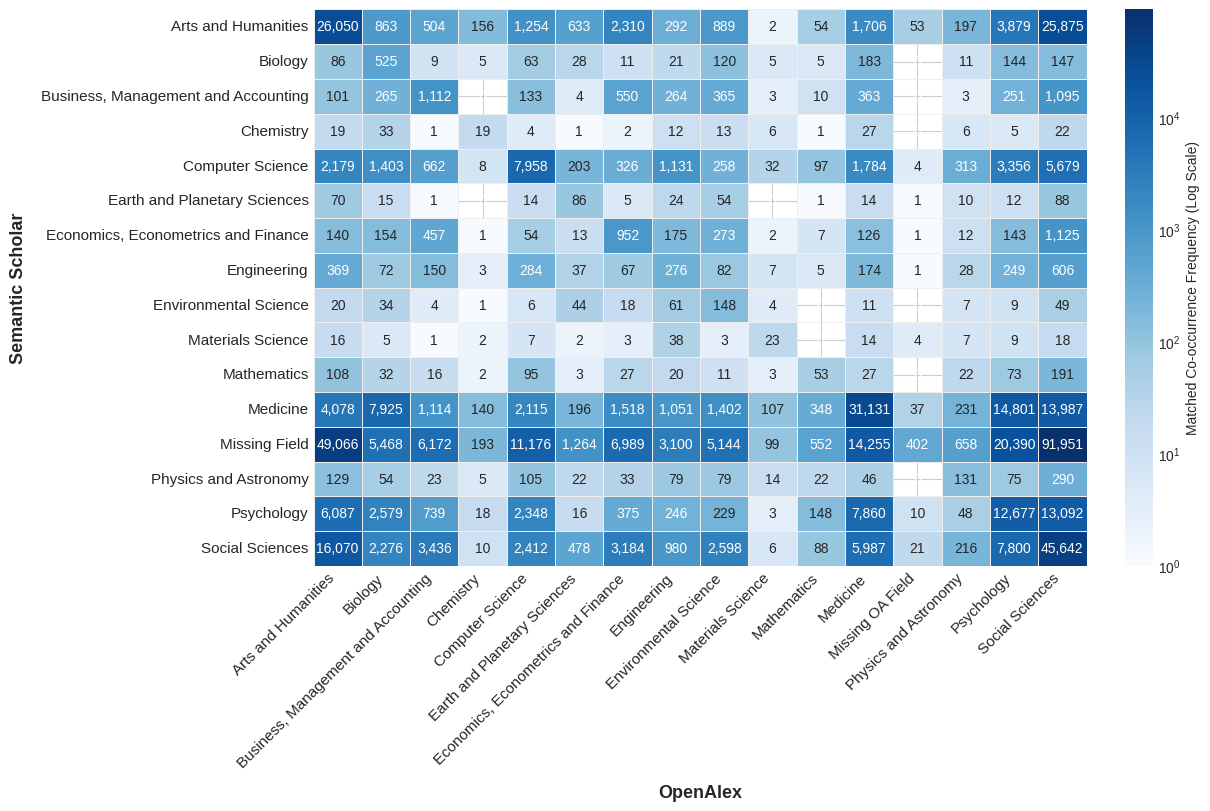

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# 1. Select the matched columns
# ============================================================

df_subset = matched_df[["oa_matched", "fos_matched"]].copy()


# ============================================================
# 2. Explode BOTH columns
#    We want ALL matched OA fields and ALL matched FOS fields,
#    rather than only the primary OA topic.
# ============================================================

df_subset = df_subset.explode("oa_matched")
df_subset = df_subset.explode("fos_matched")


# ============================================================
# 3. Clean missing values
# ============================================================

df_subset["oa_matched"] = df_subset["oa_matched"].fillna("Missing OA Field")
df_subset["fos_matched"] = df_subset["fos_matched"].fillna("Missing Field")


# ============================================================
# 4. Create contingency table
# ============================================================

df_subset["count"] = 1

contingency_table = df_subset.pivot_table(
    index="fos_matched",
    columns="oa_matched",
    values="count",
    aggfunc="sum",
    fill_value=0
)


# ============================================================
# 5. Generate heatmap
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(
    figsize=(12, 8),
    layout="constrained"
)

sns.heatmap(
    contingency_table,
    annot=True,
    fmt=",.0f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="#eee",

    # Log scale makes differences between low- and
    # high-frequency cells easier to see
    norm=LogNorm(
        vmin=max(contingency_table.values[contingency_table.values > 0].min(), 1),
        vmax=contingency_table.values.max()
    ),

    cbar_kws={
        "label": "Matched Co-occurrence Frequency (Log Scale)"
    }
)


# ============================================================
# 6. Labels and titles
# ============================================================

ax.set_xlabel(
    "OpenAlex",
    fontsize=13,
    weight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Semantic Scholar",
    fontsize=13,
    weight="bold",
    labelpad=10
)


# ============================================================
# 7. Tick formatting
# ============================================================

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)



plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Create a shallow copy to protect your original df
df_subset = oa_df[["oa_topics", "fieldsOfStudy"]].copy()

# ==================== FOCUS ON FIRST TOPIC ONLY ====================
# Instead of compiling a list of all fields, extract strictly the first dict item's field key
df_subset["field"] = df_subset["oa_topics"].apply(
    lambda x: x[0].get("field") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict)
    else (x.get("field") if isinstance(x, dict) else None)
)
df_subset = df_subset.drop(columns=["oa_topics"])
# ===================================================================

# 3. Explode ONLY fieldsOfStudy since 'field' is now a single string per paper
df_exploded = df_subset.explode("fieldsOfStudy")

# 4. Fill NAs explicitly using your exact label naming convention
df_exploded["field"] = df_exploded["field"].fillna("Missing OA Field")
df_exploded["fieldsOfStudy"] = df_exploded["fieldsOfStudy"].fillna("Missing Field")

# 5. Pivot into the contingency format
df_exploded["count"] = 1
contingency_table = df_exploded.pivot_table(
    index="fieldsOfStudy", 
    columns="field", 
    values="count", 
    aggfunc="sum", 
    fill_value=0
)


# =========================================================================

# 6. Generate the Heatmap (Using Log Scaling so variations show up nicely!)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 14), layout="constrained")

sns.heatmap(
    contingency_table, 
    annot=True, 
    fmt=",.0f", 
    cmap="Blues", 
    linewidths=0.5, 
    linecolor="#eee",
    norm=LogNorm(),  # Prevents extreme field count outliers from washing out the map
    cbar_kws={'label': 'Co-occurrence Frequency (Log Scale)'}
)

fig.suptitle("Intersection Map: Primary OpenAlex Field vs. Fields of Study", fontsize=18, weight='bold')
ax.set_title("Structured cross-tabulation table using primary OpenAlex topic alignment", fontsize=12, color='#555', pad=15)
ax.set_xlabel("Primary OpenAlex Field", fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel("Semantic Scholar Field of Study", fontsize=12, weight='bold', labelpad=10)

# Rotated slightly more since OpenAlex labels are quite lengthy
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# ==================== SAVE THE FIGURE ====================
save_path = "../results/heatmap_SeScho_OA_fos_primary.pdf"

plt.savefig(
    save_path, 
    dpi=300,              
    bbox_inches="tight",  
    transparent=False     
)
# =========================================================

plt.show()